In [26]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## **Part A: Understanding the Dataset**

In [10]:
#Q1 Dataset Overview
df = pd.read_csv('agriculture_yield_dataset.csv')
df.head()
print('Number of rows and columns:',df.shape)
print("Column names:")
print(df.columns)
print("First 10 records:")
print(df.head(10))

Number of rows and columns: (1500, 8)
Column names:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')
First 10 records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085

In [6]:
#Q2  Data Types and Missing Values
# Check data types
print("Data types of each column:")
print(df.dtypes)
#missing values
print("Missing values in each column:")
print(df.isnull().sum())

In [11]:
#Q3 Descriptive Statistics
#summary stats
print(df.describe())
# Highest Mean
print("Highest Mean:", df.select_dtypes('number').mean().idxmax())

# Highest Standard Deviation
print("Highest Std Dev:", df.select_dtypes('number').std().idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

## **Part B: Exploratory Data Analysis (EDA)**

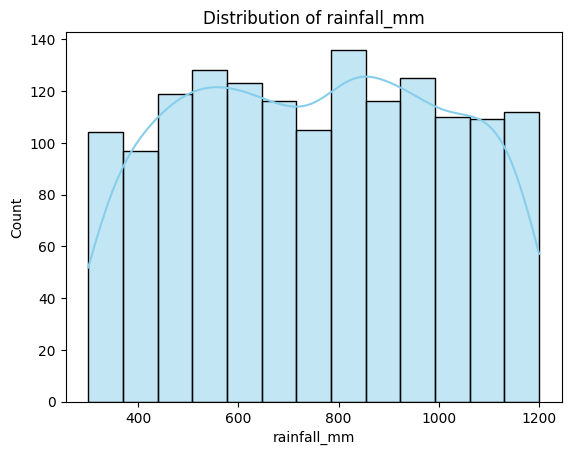

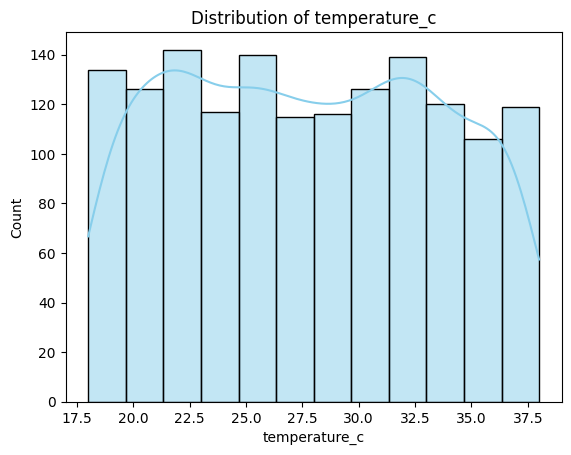

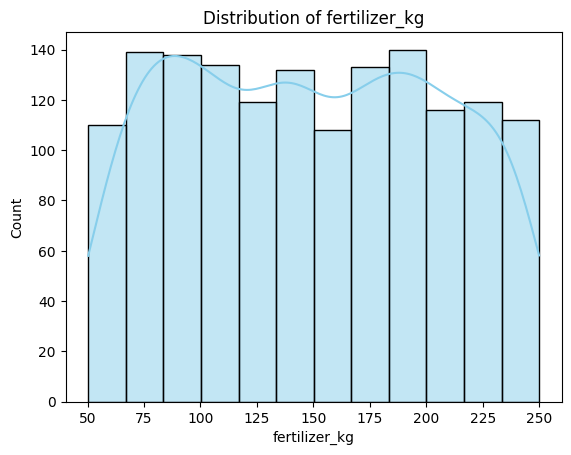

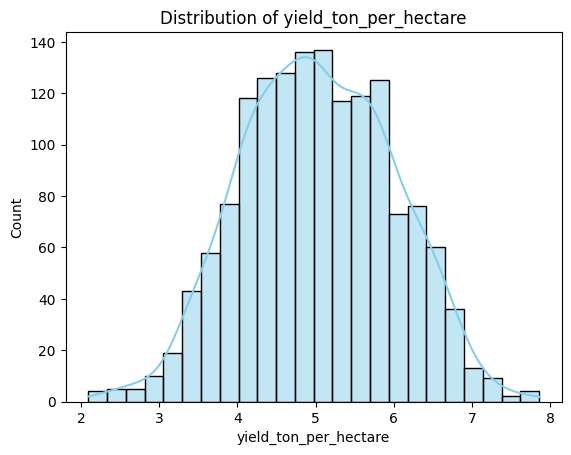

In [13]:
#Q4 Distribution Analysis
# histograms
features = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']

for col in features:
    fig, ax = plt.subplots()
    sns.histplot(data=df, x=col, kde=True, color='skyblue', ax=ax)
    ax.set_title(f'Distribution of {col}')
    plt.savefig(f'{col}_distribution.png', bbox_inches='tight')

# Observations

**1. rainfall_mm**

* **Distribution:** Approximately **Uniform** (flat-topped).
*  The values are spread nearly evenly across the entire range from $300\text{ mm}$ to $1200\text{ mm}$.
*  There is no single prominent peak or significant skewness in the data.

 **2. temperature_c**

* **Distribution:** Approximately **Uniform**.
* Data is evenly distributed between $18^\circ\text{C}$ and $38^\circ\text{C}$.
*  The mean and median sit symmetrically near the center at $\sim 27.7^\circ\text{C}$.

 **3. fertilizer_kg**

* **Distribution:** Approximately **Uniform**.
* The amount of fertilizer used shows a flat spread from $50\text{ kg}$ to $250\text{ kg}$.
*  Low, medium, and high application rates appear with almost equal frequency.

 **4. yield_ton_per_hectare**

* **Distribution:** **Normal (Bell-shaped)**.
* A clear, strong central peak forms around the average value of $5.03\text{ tons per hectare}$.
*  The frequencies taper off smoothly and symmetrically towards both the lower and higher limits.

Records per crop type:
 crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64

Most frequent crop: Cotton


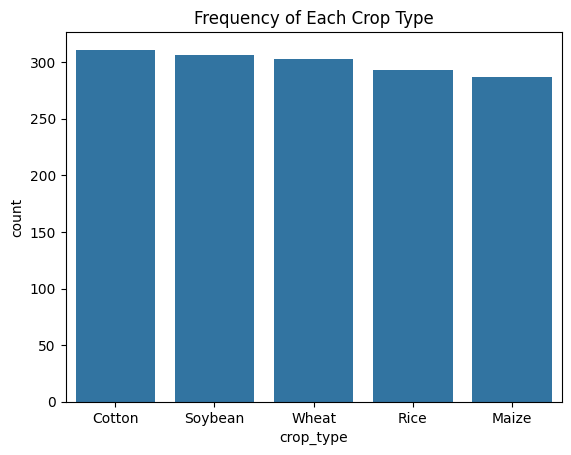

In [14]:
#Q5. Crop Type Analysis
# 1. Number of records for each crop type
crop_counts = df['crop_type'].value_counts()
print("Records per crop type:\n", crop_counts)

# 2. Most frequent crop
print("\nMost frequent crop:", crop_counts.idxmax())

# 3. Sorted count plot
fig, ax = plt.subplots()
sns.countplot(data=df, x='crop_type', order=crop_counts.index, ax=ax)
ax.set_title('Frequency of Each Crop Type')
plt.savefig('crop_type_countplot.png', bbox_inches='tight')

Frequency of each soil type:
 soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64

Most common soil type: Clay


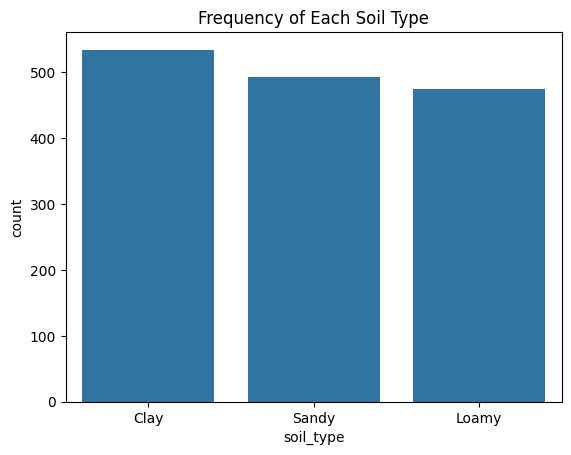

In [15]:
#Q6. Soil Type Analysis
# 1. Frequency of each soil type
soil_counts = df['soil_type'].value_counts()
print("Frequency of each soil type:\n", soil_counts)

# 2. Most common soil type
print("\nMost common soil type:", soil_counts.idxmax())

# 3. Sorted count plot
fig, ax = plt.subplots()
sns.countplot(data=df, x='soil_type', order=soil_counts.index, ax=ax)
ax.set_title('Frequency of Each Soil Type')
plt.savefig('soil_type_countplot.png', bbox_inches='tight')

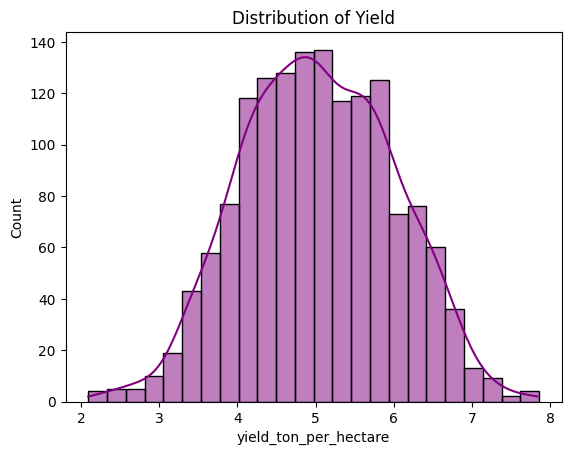

In [16]:
#Q7. Yield Distribution
fig, ax = plt.subplots()
sns.histplot(data=df, x='yield_ton_per_hectare', kde=True, color='purple', ax=ax)
ax.set_title('Distribution of Yield')
plt.savefig('yield_distribution.png', bbox_inches='tight')

* Is it approximately normal?

  Yes, it forms a clear, symmetric, bell-shaped curve centered around $5.03\text{ tons/ha}$.
* Noticeable Outliers?

  No major visual outliers. There are only $3$ minor statistical outliers at the absolute edges (two around $2.1\text{ tons/ha}$ and one at $7.86\text{ tons/ha}$), but they flow naturally within the tails.

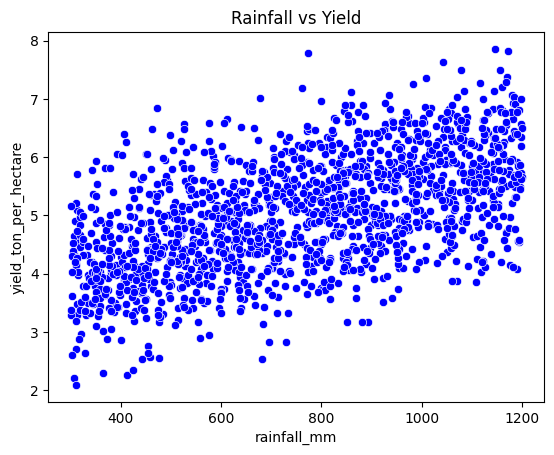

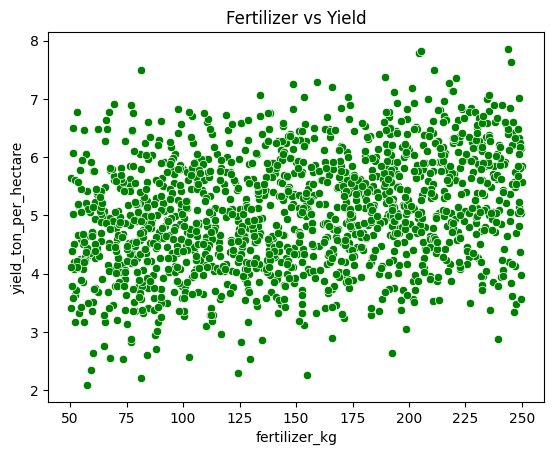

In [17]:
#Q8. Scatter Plot Analysis
# 1. Rainfall vs Yield
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='rainfall_mm', y='yield_ton_per_hectare', color='blue', ax=ax)
ax.set_title('Rainfall vs Yield')
plt.savefig('rainfall_vs_yield.png', bbox_inches='tight')

# 2. Fertilizer vs Yield
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='fertilizer_kg', y='yield_ton_per_hectare', color='green', ax=ax)
ax.set_title('Fertilizer vs Yield')
plt.savefig('fertilizer_vs_yield.png', bbox_inches='tight')

* Which feature has a stronger relationship with yield?

rainfall_mm has a significantly stronger relationship with yield than fertilizer_kg. Its scatter plot displays a tighter and more defined upward diagonal linear trend.

Correlation Matrix:
                        rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412   

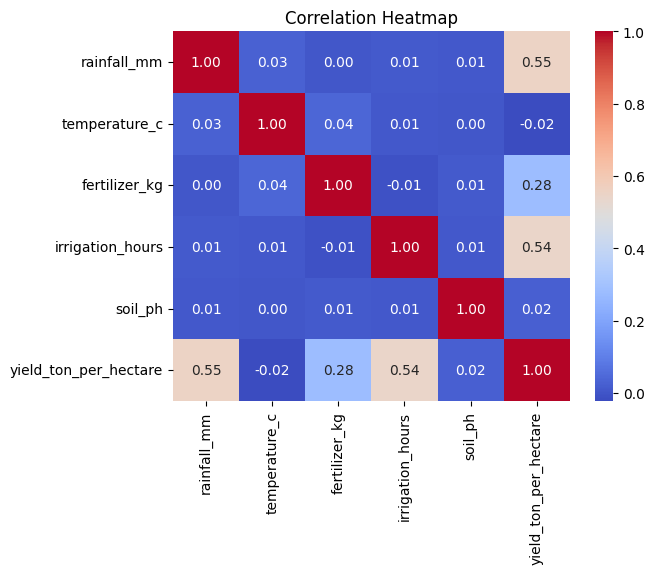

In [18]:
#Q9. Correlation Analysis
# 1. Correlation Matrix
corr_matrix = df.select_dtypes('number').corr()
print("Correlation Matrix:\n", corr_matrix)

# 2. Top 3 features most correlated with crop yield (excluding itself)
top_corr = corr_matrix['yield_ton_per_hectare'].abs().sort_values(ascending=False)
print("\nTop 3 features most correlated with yield:\n", top_corr.iloc[1:4])

# 3. Heatmap
fig, ax = plt.subplots()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
ax.set_title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')

In [23]:
#Q10. Group-Based Analysis
# 1. Average yield for each crop type
crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average Yield by Crop Type:\n", crop_yield)
print(f"\nHighest Yielding Crop: {crop_yield.idxmax()} ({crop_yield.max():.2f})")
print("\n")
# 2. Average yield for each soil type
soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False)
print("Average Yield by Soil Type:\n", soil_yield)
print(f"\nHighest Yielding Soil Type: {soil_yield.idxmax()} ({soil_yield.max():.2f})")

Average Yield by Crop Type:
 crop_type
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Maize      4.897143
Cotton     4.607299
Name: yield_ton_per_hectare, dtype: float64

Highest Yielding Crop: Rice (5.49)


Average Yield by Soil Type:
 soil_type
Loamy    5.366519
Clay     5.134326
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yielding Soil Type: Loamy (5.37)


## **Part C: Data Preparation**

In [24]:
#Q11. Feature Encoding
# 1. Identify and encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)

# 2. Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, dtype=int)

# 3. Display the first five rows
df_encoded.head()

Categorical Columns: ['crop_type', 'soil_type']


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,0,1,0,0,0,0,1,0
1,772.8,34.6,247.2,10.0,6.5,6.24,0,1,0,0,0,0,0,1
2,970.9,36.3,168.4,7.3,6.4,4.77,0,0,0,0,1,0,0,1
3,611.7,19.0,121.7,3.7,6.0,4.04,0,1,0,0,0,0,1,0
4,696.1,29.6,184.6,5.1,6.1,5.17,1,0,0,0,0,1,0,0


In [25]:
#Q12. Feature Selection
# Separate features and target
X = df_encoded.drop(columns=['yield_ton_per_hectare'])
y = df_encoded['yield_ton_per_hectare']

print("Features (X) columns:\n", list(X.columns))
print("\nTarget Variable (y): yield_ton_per_hectare")

Features (X) columns:
 ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type_Cotton', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Clay', 'soil_type_Loamy', 'soil_type_Sandy']

Target Variable (y): yield_ton_per_hectare


## **Part D: Machine Learning**

In [27]:
#Q13. Train-Test Split
# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (1200, 13)
X_test shape:  (300, 13)
y_train shape: (1200,)
y_test shape:  (300,)


In [28]:
#Q14. Linear Regression Model
# 1. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Display intercept and coefficients
print(f"Intercept: {model.intercept_:.4f}\n")
print("Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"  {col}: {coef:.4f}")

Intercept: 1.9111

Coefficients:
  rainfall_mm: 0.0020
  temperature_c: -0.0092
  fertilizer_kg: 0.0050
  irrigation_hours: 0.1983
  soil_ph: 0.0049
  crop_type_Cotton: -0.3866
  crop_type_Maize: -0.1477
  crop_type_Rice: 0.4774
  crop_type_Soybean: 0.0951
  crop_type_Wheat: -0.0381
  soil_type_Clay: 0.0627
  soil_type_Loamy: 0.3656
  soil_type_Sandy: -0.4283


* Which feature has the highest positive coefficient?

  crop_type_Rice (with a coefficient value of 0.4774), meaning planting rice has the highest independent positive impact on predicting yield in this linear model.